# <u>Clustering</u>

In [27]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

sns.set()

## Lectura de datos

In [12]:
df_customers = pd.read_csv("https://assets.datacamp.com/production/repositories/5838/datasets/083224d85bfe51f091d9641fbfc95e60ba95c0ba/Mall_Customers.csv")

In [13]:
mapping = {'Male': 0, 'Female':1}

df_customers["Gender"] = df_customers["Gender"].map(mapping)
df_customers.columns = ['id', 'sexo', 'edad', 'ingreso', 'score']

In [14]:
df_customers.head()

,id,sexo,edad,ingreso,score
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


## Clustering con dos variables

In [15]:
df_clustering = df_customers[['edad', 'score']]
df_clustering.head()

,edad,score
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40


In [18]:
model = KMeans(n_clusters = 3)

In [19]:
model.fit(df_clustering)

KMeans(n_clusters=3)

In [20]:
model.predict(df_clustering)

array([1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2,
       0, 2, 0, 2, 1, 1, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 1,
       0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2], dtype=int32)

In [21]:
df_clustering['cluster'] = model.predict(df_clustering)
df_clustering.head()

/tmp/ipykernel_12116/4060935650.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clustering['cluster'] = model.predict(df_clustering)


,edad,score,cluster
0,19,39,1
1,21,81,2
2,20,6,0
3,23,77,2
4,31,40,1


In [22]:
df_clustering['cluster'].value_counts()

,count
cluster,
1,92
2,62
0,46


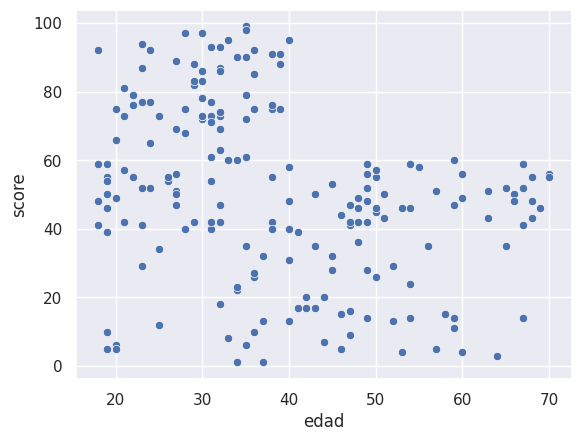

In [23]:
sns.scatterplot(data = df_clustering, x = 'edad', y = 'score')
plt.show()

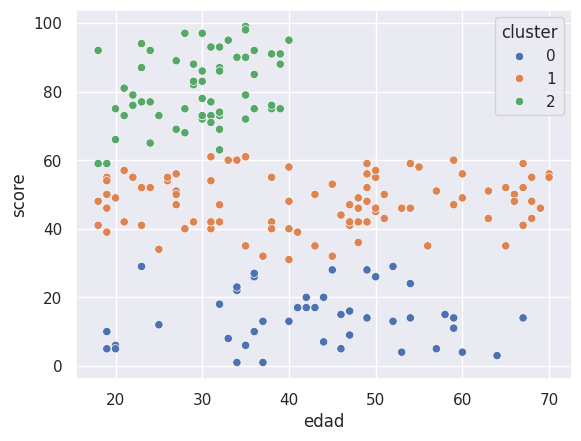

In [24]:
sns.scatterplot(data = df_clustering, x = 'edad', y = 'score', hue = 'cluster', palette = 'deep')
plt.show()

## Preprocesamiento de variables

In [25]:
df_clustering = df_customers[['edad', 'score']]

In [26]:
df_clustering.head()

,edad,score
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40


In [28]:
scaler = MinMaxScaler()

In [29]:
df_scaled = pd.DataFrame(scaler.fit_transform(df_clustering),columns = df_clustering.columns)
df_scaled.head()

,edad,score
0,0.019231,0.387755
1,0.057692,0.816327
2,0.038462,0.051020
3,0.096154,0.775510
4,0.250000,0.397959


## clustering con variables escaladas

In [30]:
model = KMeans(n_clusters = 3)

In [31]:
model.fit(df_scaled)

KMeans(n_clusters=3)

In [32]:
model.predict(df_scaled)

array([0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2, 1, 2, 0, 2,
       0, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2,
       1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2,
       2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 1, 2, 0, 1, 1, 2, 1, 0, 1, 1, 1, 1,
       1, 2, 0, 2, 2, 2, 1, 1, 1, 1, 2, 0, 2, 2, 0, 2, 0, 2, 1, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2,
       1, 2, 1, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2], dtype=int32)

In [33]:
df_clustering['cluster'] = model.predict(df_scaled)
df_clustering.head()

/tmp/ipykernel_12116/931445122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clustering['cluster'] = model.predict(df_scaled)


,edad,score,cluster
0,19,39,0
1,21,81,2
2,20,6,0
3,23,77,2
4,31,40,0


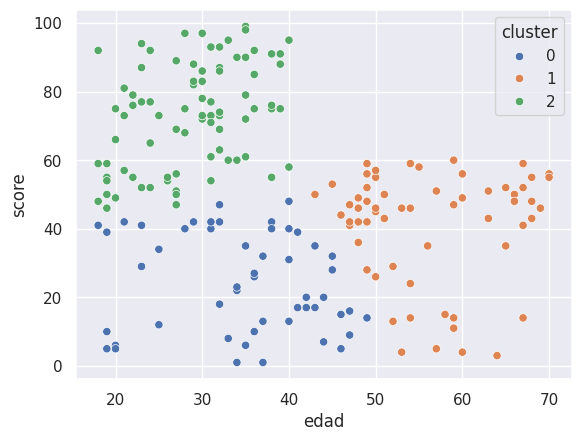

In [34]:
sns.scatterplot(data = df_clustering, x = 'edad', y = 'score', hue = 'cluster', palette = 'deep')
plt.show()

## Descriptivos de clustering

In [35]:
df_clustering.head()

,edad,score,cluster
0,19,39,0
1,21,81,2
2,20,6,0
3,23,77,2
4,31,40,0


In [36]:
df_clustering['cluster'].value_counts()

,count
cluster,
2,85
1,62
0,53


In [37]:
df_clustering.groupby('cluster').mean()

,edad,score
cluster,,
0,34.981132,24.433962
1,56.080645,40.306452
2,28.694118,73.482353


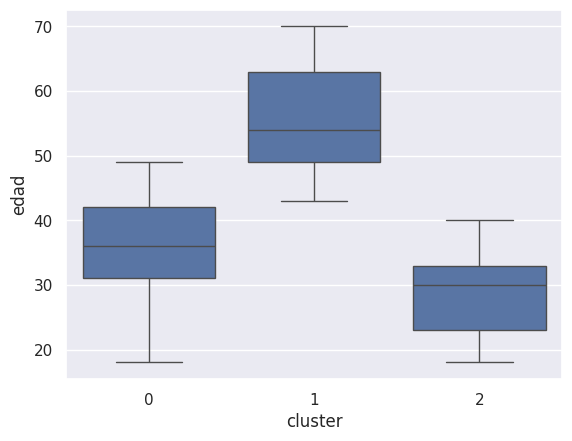

In [38]:
sns.boxplot(data = df_clustering, y = 'edad', x = 'cluster')
plt.show()

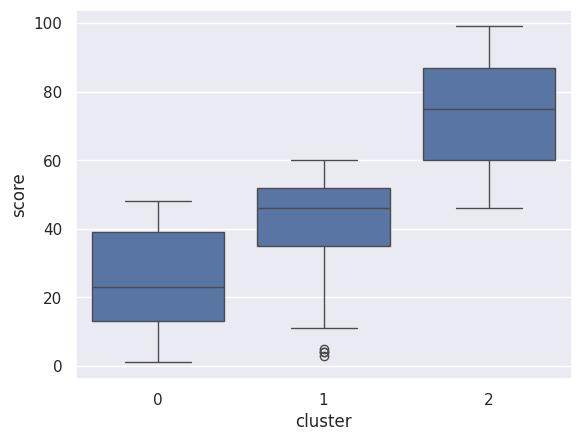

In [39]:
sns.boxplot(data = df_clustering, y = 'score', x = 'cluster')
plt.show()

## Clustering con más variables

In [40]:
df_customers.head()

,id,sexo,edad,ingreso,score
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [41]:
df_clustering = df_customers[['edad', 'ingreso', 'score']]
df_clustering.head()

,edad,ingreso,score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [42]:
scaler = MinMaxScaler()

In [43]:
df_scaled = pd.DataFrame(scaler.fit_transform(df_clustering),columns = df_clustering.columns)
df_scaled.head()

,edad,ingreso,score
0,0.019231,0.000000,0.387755
1,0.057692,0.000000,0.816327
2,0.038462,0.008197,0.051020
3,0.096154,0.008197,0.775510
4,0.250000,0.016393,0.397959


In [44]:
model = KMeans(n_clusters = 3)
model.fit(df_scaled)

KMeans(n_clusters=3)

In [45]:
df_customers['cluster'] = model.predict(df_scaled)

In [46]:
df_customers.head()

,id,sexo,edad,ingreso,score,cluster
0,1,0,19,15,39,2
1,2,0,21,15,81,2
2,3,1,20,16,6,2
3,4,1,23,16,77,2
4,5,1,31,17,40,2


In [47]:
df_customers['cluster'].value_counts()

,count
cluster,
1,96
2,64
0,40


In [48]:
df_customers.groupby('cluster').mean()

,id,sexo,edad,ingreso,score
cluster,,,,,
0,161.025000,0.550000,32.875000,86.100000,81.52500
1,100.312500,0.552083,50.479167,61.093750,33.40625
2,62.953125,0.578125,25.140625,43.796875,55.81250


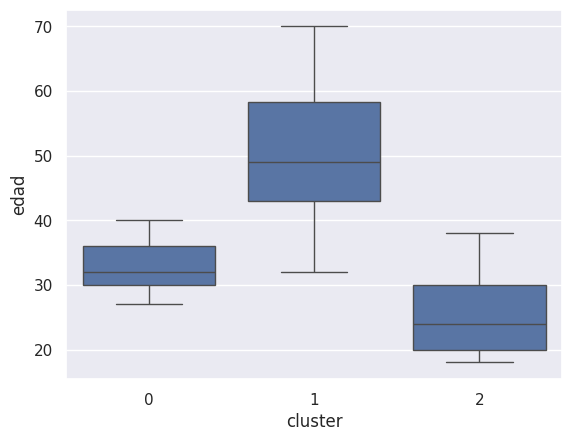

In [49]:
sns.boxplot(data = df_customers, y = 'edad', x = 'cluster')
plt.show()

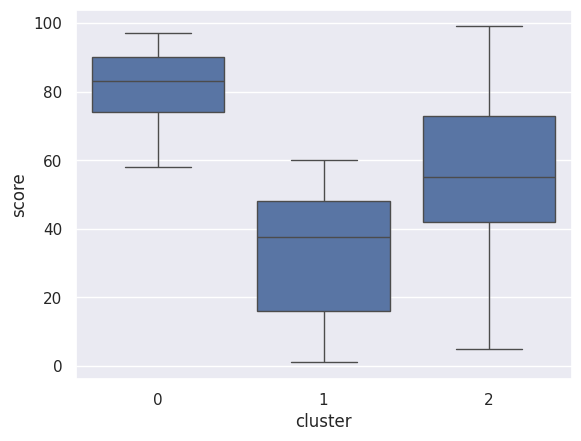

In [50]:
sns.boxplot(data = df_customers, y = 'score', x = 'cluster')
plt.show()

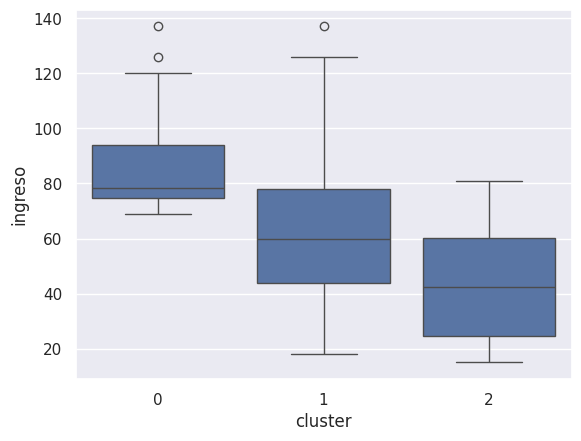

In [51]:
sns.boxplot(data = df_customers, y = 'ingreso', x = 'cluster')
plt.show()

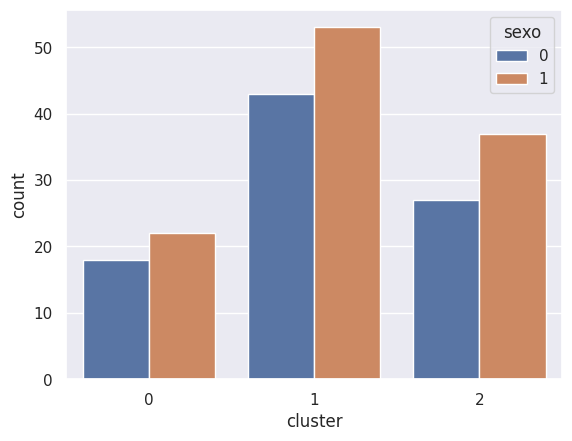

In [52]:
sns.countplot(data = df_customers, x = 'cluster', hue = 'sexo')
plt.show()